## Load Data and Initialize Spark

In this section, we set up the project paths and import the required Python and PySpark libraries.  
We add the project root to Python's path so that custom modules in `src/` can be imported.  

Next, we create a SparkSession using our `create_spark_session` function and load all datasets into PySpark DataFrames using `load_dataframes`.  

The loaded datasets include: `category`, `customer`, `product`, `transaction`, `browsing_behaviour`, `customer_session`, and `fraud_transaction`.  

In [1]:
import sys
import os
from pyspark.sql.types import DoubleType, IntegerType, StringType, BooleanType, FloatType, LongType
from pyspark.sql.functions import isnan, when, count, col
from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = os.path.abspath("..")
sys.path.append(PROJECT_ROOT)
DATA_PATH = os.path.join(PROJECT_ROOT, "data")

from src.data_loading import create_spark_session, load_dataframes
from src.feature_engineering import create_features, prepare_features_for_clustering
from src.model_training import prepare_features_for_ml, create_pipelines, train_and_evaluate, compute_metrics, plot_roc_curve
from src.kmeans_module import prepare_kmeans_features, train_kmeans, silhouette_vs_k, evaluate_kmeans

# Create SparkSession
spark, sc = create_spark_session(app_name="ML")

# Load DataFrames
dfs = load_dataframes(spark, DATA_PATH)


We then display a few rows from each DataFrame, print schemas, and check the total number of transactions to confirm the data was loaded correctly.

In [2]:
# Check data
dfs["category"].show(2)
dfs["customer"].show(2)
dfs["product"].show(2)
dfs["transaction"].show(2)
dfs["transaction"].printSchema()
dfs["transaction"].count()
dfs["browsing_behaviour"].show(2)
dfs["customer_session"].show(2)
dfs["fraud_transaction"].show(2)

+-----------+-------------+----------+----------+
|category_id|   cat_level1|cat_level2|cat_level3|
+-----------+-------------+----------+----------+
|          1|Personal Care|    Makeup|   Compact|
|          2|   Free Items|Free Gifts|      Ties|
+-----------+-------------+----------+----------+
only showing top 2 rows

+-----------+----------+----------+--------------------+--------------------+------+----------+---------------+
|customer_id|first_name| last_name|            username|               email|gender| birthdate|first_join_date|
+-----------+----------+----------+--------------------+--------------------+------+----------+---------------+
|       2870|      Lala|   Maryati|671a0865-ac4e-4dc...|671a0865_ac4e_4dc...|     F|1996-06-14|     2019-07-21|
|       8193|  Maimunah|Laksmiwati|83be2ba7-8133-48a...|83be2ba7_8133_48a...|     F|1993-08-16|     2017-07-16|
+-----------+----------+----------+--------------------+--------------------+------+----------+---------------+
onl

In [3]:
dfs["transaction"].count()

657989

## Data Transformation and Feature Engineering

In this step, we transform the raw data into features suitable for machine learning. The main tasks performed are:

1. **Browsing Behaviour Analysis**  
   The browsing behaviour dataset contains 10 types of events:  
   `VC` (Viewing Category), `VI` (Viewing Item), `VP` (Viewing Promotion), `AP` (Add Promotion),  
   `CL` (Click), `ATC` (Add to Cart), `CO` (Checkout), `HP` (Home Page), `SCR` (Scroll), `SER` (Search).  
   Events are grouped into three levels:  
   - **L1**: Actions highly likely to lead to a purchase (`AP`, `ATC`, `CO`)  
   - **L2**: Actions that may lead to a purchase (`VC`, `VP`, `VI`, `SER`)  
   - **L3**: Browsing actions with low purchase impact (`SCR`, `HP`, `CL`)  

   For each transaction, we count the number of actions in each level and calculate their ratios.

2. **Browsing Time and Time of Day**  
   The average event time per session is computed and categorized into `morning`, `afternoon`, `evening`, or `night`.

3. **Customer Information**  
   We merge transaction and customer data to include features such as:  
   - Gender  
   - Age (calculated from birthdate)  
   - Year of first joining  
   - Number of successful purchases

4. **Transaction Labels and Grid Quantisation**  
   - Fraud labels are attached (`is_fraud` and numeric `labels`)  
   - Geographic data (latitude and longitude) is simplified using grid quantisation for analysis.

The `create_features` function in `src.feature_engineering` performs all these transformations, producing a clean feature DataFrame ready for machine learning tasks.

In [4]:
# Create features
features_df, features_df2 = create_features(
    transaction=dfs["transaction"],
    browsing_behaviour=dfs["browsing_behaviour"],
    customer=dfs["customer"],
    fraud_transaction=dfs["fraud_transaction"]
)

# Show results
features_df.show(5)
features_df.printSchema()

+-----------------+----------------+------+---+---------------+-------------------+---+---+---+-------+-------+-----------+--------+------+--------+---------+
|              lat|            long|gender|age|first_join_year|number_of_purchases| l1| l2| l3|l1ratio|l2ratio|time_of_day|is_fraud|labels|lat_grid|long_grid|
+-----------------+----------------+------+---+---------------+-------------------+---+---+---+-------+-------+-----------+--------+------+--------+---------+
|  2.3298059586444|98.2288159663493|     M| 33|           2019|                 19|  3| 13| 20|   8.33|  36.11|  afternoon|   false|     0|     2.0|     98.0|
|-7.58254899601518|110.481246296543|     F| 28|           2016|                105|  2|  1|  1|   50.0|   25.0|    evening|   false|     0|    -8.0|    110.0|
|-1.72555902403085|115.621543783968|     F| 33|           2019|                 42|  3|  1|  4|   37.5|   12.5|      night|   false|     0|    -2.0|    115.5|
|-6.35096454964097|106.883101361694|     F| 40

## Data Preparation for K-Means Clustering

In this step, we prepare features to identify patterns of fraudulent behavior. The transformations include:

- **Session-level features:** L1/L2/L3 ratios, L3 session duration, ATC activity.
- **Customer-level features:** Aggregated L ratios across all sessions, failed payment counts, price preferences, repeated purchases.
- **Suspicious patterns:** Small transactions in short intervals, multiple attempts with stolen credit cards.
- **Final dataset:** Combines transaction, browsing behaviour, and customer-level features into a single DataFrame ready for clustering or ML tasks.

In [5]:
features_knn = prepare_features_for_clustering(
    features=features_df2,
    transaction=dfs["transaction"],
    browsing_behaviour=dfs["browsing_behaviour"],
    customer=dfs["customer"],
    customer_session=dfs["customer_session"],
    fraud_transaction=dfs["fraud_transaction"]
)

# Show results
features_knn.show(5)
features_knn.printSchema()

+---+-------+-------+-------+---------------+---------+-----+-------------+---------+-----------+----------+------+---------+--------+------+
| l3|l1ratio|l2ratio|l3ratio|several_l3_time|expensive|cheap|expensive_rat|cheap_rat|fail_number|fail_ratio|bigATC|was_fraud|is_fraud|labels|
+---+-------+-------+-------+---------------+---------+-----+-------------+---------+-----------+----------+------+---------+--------+------+
|  3|   40.0|   30.0|   30.0|        2991.67|        0|    0|          0.0|      0.0|          3|      0.25|   yes|        0|   false|     0|
|  8|   25.0|   25.0|   50.0|        1532.57|        0|    0|          0.0|      0.0|        117|      0.56|   yes|        4|   false|     0|
|  1|   60.0|   20.0|   20.0|            0.0|        0|    0|          0.0|      0.0|          0|       0.0|    no|        0|   false|     0|
|  4|   37.5|   12.5|   50.0|           24.9|        1|    0|        100.0|      0.0|          5|      0.83|   yes|        0|   false|     0|
|  3| 

## Exploring the Data
With the `feature_df`, we explore the dataset using both descriptive statistics and categorical summaries.

### **(a) Numeric Columns**
For each numeric column, we compute:
- **count**
- **mean**
- **standard deviation**
- **minimum and maximum values**
- **25th, 50th, and 75th percentiles**

This provides a clear overview of the distribution and statistical spread of the numerical features.

### **(b) Categorical Columns**
For each non-numeric (categorical) column, we display:
- **Top-5 most frequent values**
- **Corresponding counts**

This helps to understand category dominance and distribution.

### **(c) Boolean Columns**
For each boolean column, we compute:
- **Value counts**

This is useful for identifying class balance and detecting possible skew.

In [6]:
# Look at format od the data.
features_df.printSchema()

root
 |-- lat: double (nullable = true)
 |-- long: double (nullable = true)
 |-- gender: string (nullable = true)
 |-- age: long (nullable = true)
 |-- first_join_year: integer (nullable = true)
 |-- number_of_purchases: long (nullable = true)
 |-- l1: long (nullable = true)
 |-- l2: long (nullable = true)
 |-- l3: long (nullable = true)
 |-- l1ratio: double (nullable = true)
 |-- l2ratio: double (nullable = true)
 |-- time_of_day: string (nullable = true)
 |-- is_fraud: boolean (nullable = false)
 |-- labels: integer (nullable = false)
 |-- lat_grid: double (nullable = true)
 |-- long_grid: double (nullable = true)



In [7]:
# Remove rows with null values in 'number_of_purchases'
features_df = features_df.filter(F.col("number_of_purchases").isNotNull())

# Function to count missing values in each column
def count_missing(c):
    # For numeric columns, consider NaN, null, and '?' as missing
    if isinstance(features_df.schema[c].dataType, (DoubleType, FloatType)):
        return F.count(when(isnan(c) | col(c).isNull() | (col(c) == '?'), c)).alias(c)
    # For boolean, string, or integer types, consider null or '?' as missing
    elif isinstance(features_df.schema[c].dataType, (BooleanType, StringType, IntegerType, LongType)):
        return F.count(when(col(c).isNull() | (col(c) == '?'), c)).alias(c)
    # For other types, only consider null as missing
    else:
        return F.count(when(col(c).isNull(), c)).alias(c)

# Apply the function to all columns
missing_values_count = features_df.select([count_missing(c) for c in features_df.columns])
missing_values_count.show()

+---+----+------+---+---------------+-------------------+---+---+---+-------+-------+-----------+--------+------+--------+---------+
|lat|long|gender|age|first_join_year|number_of_purchases| l1| l2| l3|l1ratio|l2ratio|time_of_day|is_fraud|labels|lat_grid|long_grid|
+---+----+------+---+---------------+-------------------+---+---+---+-------+-------+-----------+--------+------+--------+---------+
|  0|   0|     0|  0|              0|                  0|  0|  0|  0|      0|      0|          0|       0|     0|       0|        0|
+---+----+------+---+---------------+-------------------+---+---+---+-------+-------+-----------+--------+------+--------+---------+



### Explore Numeric Features

In [8]:
# Select numeric columns by dropping categorical and boolean columns
features_df_numeric = features_df.drop('gender', 'time_of_day', 'is_fraud')

# Compute basic descriptive statistics using describe()
describe_pd = features_df_numeric.describe().toPandas()

# Define percentiles to compute
percentiles = [0.25, 0.50, 0.75]
percentile_stats = {}

# Compute approximate percentiles for each numeric column
for col in features_df_numeric.columns:
    quantiles = features_df_numeric.approxQuantile(col, percentiles, 0.01)
    percentile_stats[col] = quantiles

# Update the describe DataFrame with the computed percentiles
for col, quantiles in percentile_stats.items():
    describe_pd.loc['25%', col] = quantiles[0]
    describe_pd.loc['50%', col] = quantiles[1]
    describe_pd.loc['75%', col] = quantiles[2]

# Display descriptive statistics with percentiles
describe_pd

,summary,lat,long,age,first_join_year,number_of_purchases,l1,l2,l3,l1ratio,l2ratio,labels,lat_grid,long_grid
0,count,650691,650691,650691,650691,650691,650691,650691,650691,650691,650691,650691,650691,650691
1,mean,-5.1094774316321105,110.97223363959164,25.714959942584116,2018.2765521576293,40.321321487464864,3.7027621405551945,3.6098762699960503,8.238664742558296,34.05788011513839,19.131629006702667,0.01629959535324755,-5.364652346505484,110.70705603735107
2,stddev,3.0828299124577594,6.4093860617068374,7.407295450335853,1.454914147275832,47.115076890483365,2.3460754192718256,4.544250542282847,10.080557136257008,18.755211872355446,12.8913051638808,0.1266252075456429,3.0869035414232644,6.421468842606626
3,min,-10.995516358954,95.0307281029158,4,2016,1,2,0,1,0.41,0.0,0,-11.0,95.0
4,max,5.87479130345884,141.006140001985,69,2021,396,54,157,512,96.55,71.43,1,5.5,141.0
25%,NaN,-7.356977,106.854718,20.0,2017.0,11.0,2.0,1.0,2.0,18.75,10.0,0.0,-7.5,106.5
50%,NaN,-6.244586,110.142288,25.0,2018.0,25.0,3.0,2.0,5.0,33.33,20.0,0.0,-6.5,110.0
75%,NaN,-3.158962,113.055461,30.0,2019.0,52.0,4.0,5.0,10.0,50.0,28.57,0.0,-3.5,113.0


### Top Values for Categorical Columns
We cannot display the top five categories because our DataFrame has only two categorical columns, which contain 2 and 4 possible categories, respectively. Instead, we will show the existing categories in descending order.

In [9]:
#Find categorical features.
features_df_cat = features_df.select('gender', 'time_of_day')
for column in features_df_cat.columns:
    print(f"For {column} (5) top values are:")
    df_column = features_df_cat.groupBy(column)\
                .agg(F.count('*').alias('count'))\
                .orderBy(F.col("count").desc())
    df_column.show(5)

For gender (5) top values are:
+------+------+
|gender| count|
+------+------+
|     F|415802|
|     M|234889|
+------+------+

For time_of_day (5) top values are:
+-----------+------+
|time_of_day| count|
+-----------+------+
|    evening|163946|
|  afternoon|163475|
|    morning|161905|
|      night|161365|
+-----------+------+



### Value Counts for Boolean Columns
Display the count of each unique value for boolean features to understand class balance.

In [10]:
features_df_bool = features_df.select('is_fraud')
for column in features_df_bool.columns:
    print(f"For {column}  top values are:")
    df_column = features_df_bool.groupBy(column)\
                .agg(F.count('*').alias('count'))\
                .orderBy(F.col("count").desc())
    df_column.show(5)

For is_fraud  top values are:
+--------+------+
|is_fraud| count|
+--------+------+
|   false|640085|
|    true| 10606|
+--------+------+



### Data Exploration and Plots

We present two plots to visualize key patterns in the dataset. One plot focuses on fraudulent behaviour, while the other explores demographic distribution.

#### Plot 1: Scatter Plot of L1ratio vs L2ratio

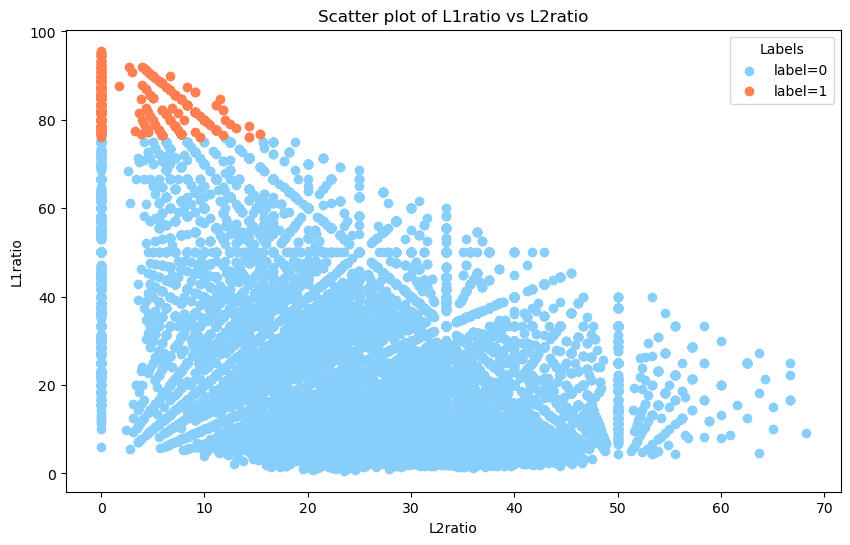

In [11]:
# Sample df
sample_df = features_df.sampleBy("labels", fractions={0: 0.1, 1: 0.1}, seed=123)
sample_data = sample_df.collect()


plt.figure(figsize=(10, 6))

colors = {0: 'lightskyblue', 1: 'coral'}
# Use subset because previously it gave me incorrect legend.
for label in colors:
    subset = [row for row in sample_data if row.labels == label]
    plt.scatter([row.l2ratio for row in subset], [row.l1ratio for row in subset], color=colors[label], label=f'label={label}')

plt.title("Scatter plot of L1ratio vs L2ratio")
plt.xlabel("L2ratio")
plt.ylabel("L1ratio")
plt.legend(title="Labels")
plt.show()

The scatter plot shows transactions colored by fraud status. Transactions with an L1 ratio above 75% are mostly fraudulent, while those below are non-fraudulent. Fraudulent transactions appear only when L2 ratio is below 20%, but non-fraudulent ones still occur in this range. This indicates that L1 ratio strongly separates fraudulent from normal transactions, while L2 ratio has some influence.

#### Plot 2: Bar Chart of Fraud by Gender (L1ratio 70–85%)

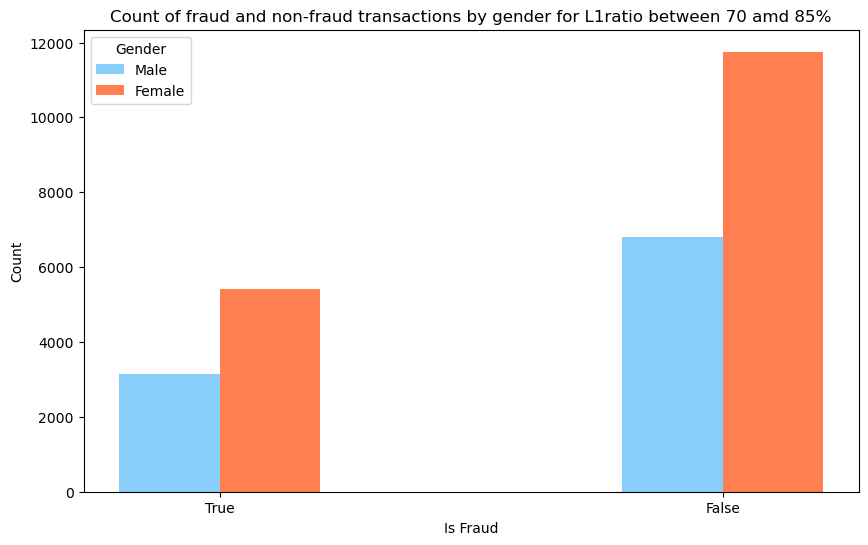

In [12]:
# Filter data for L1rastion between 70 and 85%.
filtered_df = features_df.filter((F.col('l1ratio') >= 70) & (F.col('l1ratio') <= 85))
# Count numbers of male and female.
grouped_df = filtered_df.groupBy('is_fraud', 'gender')\
                        .agg(F.count('*').alias('count'))
# Collect data for plot.
grouped_data = grouped_df.collect()
fraud_labels = ['True', 'False']
male_counts = [0, 0]
female_counts = [0, 0]

for row in grouped_data:
    if row['is_fraud']:
        if row['gender'] == 'M':
            male_counts[0] = row['count']
        else:
            female_counts[0] = row['count']
    else:
        if row['gender'] == 'M':
            male_counts[1] = row['count']
        else:
            female_counts[1] = row['count']

# Plot graph.
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
index = range(len(fraud_labels))

bar1 = ax.bar(index, male_counts, bar_width, label='Male', color='lightskyblue')
bar2 = ax.bar([i + bar_width for i in index], female_counts, bar_width, label='Female', color='coral')

ax.set_xlabel('Is Fraud')
ax.set_ylabel('Count')
ax.set_title('Count of fraud and non-fraud transactions by gender for L1ratio between 70 amd 85%')
ax.set_xticks([i + bar_width / 2 for i in index])
ax.set_xticklabels(fraud_labels)
ax.legend(title='Gender')


plt.show()

This bar chart shows fraud distribution by gender in the L1 ratio range 70–85%, where both fraud and non-fraud transactions occur. The results indicate that fraudulent transactions are evenly distributed across genders. Gender does not appear to be a useful feature for further analysis.

From the statistical analysis of the columns, key metrics like maximum, minimum values, and standard deviation are important because they help identify features with more distinguishable values, which are better suited for model training. For instance, the "first_join_year" can be immediately excluded due to its narrow range and low standard deviation. Analyzing the graphs, it is clear that the "L1 ratio" has a significant impact on the labels and must be included in the model. Similarly, the "L2 ratio" also shows influence. The "gender" feature, however, can be excluded as it does not provide any distinguishing effect on the labels. Longitude and latitude, by themselves, are not useful, so I applied grid quantization to group geographical data into manageable sections for analysis. This transformation simplifies the data, making it more actionable for detecting spatial patterns. Initially, I considered excluding "L1," "L2," and "L3" because I thought they were redundant, but through trial and error, I found that including these features improved the model's performance. Therefore, the final set of features includes:

- 'time_of_day'
- 'latitude'
- 'number_of_purchases'
- 'L1'
- 'L2'
- 'L3'
- 'L1 ratio'
- 'L2 ratio'

# Part 2: Feature Extraction and ML Training

In this section, we prepare features for ML models, create ML pipelines, train Random Forest and Gradient Boosted Tree models, and evaluate their performance on test data.

In [13]:
# Import functions from src
from src.model_training import prepare_features_for_ml, create_pipelines, train_and_evaluate


## Feature Selection and Transformation

We select features based on our previous data exploration (Part 1).  
Numeric and categorical columns are prepared for ML pipelines.

In [14]:
# Prepare numeric and categorical columns
numeric_cols, categorical_cols = prepare_features_for_ml(features_df)

print("Numeric columns for ML:", numeric_cols)
print("Categorical columns for ML:", categorical_cols)

Numeric columns for ML: ['number_of_purchases', 'l1', 'l2', 'l3', 'l1ratio', 'l2ratio', 'labels', 'lat_grid']
Categorical columns for ML: ['time_of_day']


## Creating ML Pipelines

We create ML pipelines including:
1. StringIndexer for categorical columns  
2. OneHotEncoder for indexed categorical columns  
3. VectorAssembler for combining all features  
4. Random Forest (RF) and Gradient Boosted Tree (GBT) classifiers

In [15]:
# Create ML pipelines for RF and GBT
pipeline_rf, pipeline_gbt = create_pipelines(numeric_cols, categorical_cols)

## Preparing Training and Testing Data

We use stratified sampling to reduce dataset size and split it into training and testing sets (70% / 30%).

In [16]:
# Split data for training and testing
fractions = features_df.select("labels").distinct().rdd.map(lambda x: (x[0], 0.2)).collectAsMap()
sampled_df = features_df.sampleBy("labels", fractions, seed=123)
train_df, test_df = sampled_df.randomSplit([0.7, 0.3], seed=123)

print(f"Training data count: {train_df.count()}, Testing data count: {test_df.count()}")

Training data count: 91251, Testing data count: 38716


##  Training Models and Evaluation


1. **Random Forest (RF)** – an ensemble of decision trees, which reduces overfitting and improves accuracy.  
2. **Gradient Boosted Tree (GBT)** – sequentially builds trees to correct errors from previous ones, often achieving better predictive performance.

We will train both models on a sampled dataset and evaluate their performance using metrics such as accuracy, precision, recall, F1-score, confusion matrix, and AUC. Additionally, we visualize the model performance with a ROC curve.

We use the prepared features and categorical encoding pipelines from the previous steps to ensure that the models receive properly formatted input.

In [17]:
# Train models and evaluate
predictions_rf, predictions_gbt = train_and_evaluate(train_df, test_df, pipeline_rf, pipeline_gbt)


Quick AUC check - RF: 1.0000, GBT: 1.0000


In [18]:
print("\nRandom Forest Metrics:")
rf_accuracy, rf_precision, rf_recall, rf_f1 = compute_metrics(predictions_rf, "Random Forest")



Random Forest Metrics:

For Random Forest:
+------+----------+-----+
|labels|prediction|count|
+------+----------+-----+
|     0|       0.0|38051|
|     1|       1.0|  626|
|     0|       1.0|   39|
+------+----------+-----+

TN: 38051, TP: 626, FN: 0, FP: 39
Accuracy: 0.9989926645314599, Precision: 0.9413533834586466, Recall: 1.0, F1: 0.9697908597986058


In [19]:
print("\nGradient Boosted Tree Metrics:")
gbt_accuracy, gbt_precision, gbt_recall, gbt_f1 = compute_metrics(predictions_gbt, "Gradient Boosted Tree")



Gradient Boosted Tree Metrics:

For Gradient Boosted Tree:
+------+----------+-----+
|labels|prediction|count|
+------+----------+-----+
|     1|       0.0|    1|
|     0|       0.0|38082|
|     1|       1.0|  625|
|     0|       1.0|    8|
+------+----------+-----+

TN: 38082, TP: 625, FN: 1, FP: 8
Accuracy: 0.9997675379687985, Precision: 0.9873617693522907, Recall: 0.9984025559105432, F1: 0.9928514694201748


In [ ]:
# Take a sample from predictions
sampled_predictionsgbt = predictions_gbt.sample(fraction=0.001, seed=123)  

# Then pass this sample to your existing function
plot_roc_curve(sampled_predictionsgbt, "Gradient Boosted Tree")


It looks like both models perform very well on the data and predict the labels accurately. All accuracy, recall, and precision values are close to one, and the AUC is also very high. The Gradient Boosting Tree (GBT) model performs slightly better, so I will select it as the best model. There is no need to fine-tune the internal parameters since the model already works exceptionally well.

# Part 3: Customer Clustering and Knowledge Sharing with K-Means

In this section, we apply **K-Means clustering** to explore patterns of customer behavior and potential fraud. Despite having many features from the exploratory phase, some were excluded because they were redundant or not indicative of fraud.  

- `l2ratio` was excluded as we already have `l1ratio` and `l3ratio`.  
- `l3` was removed since the time between multiple `l3` events is unreliable.  
- Absolute counts of expensive, cheap, and failed transactions were removed; only the ratios were retained.  
- Previous customer activity features were excluded since fraudsters can exploit stolen cards with a good historical record.

We also created a **balanced dataset** to handle class imbalance:
- Oversample fraud (`labels = 1`) to 10500 rows  
- Undersample non-fraud (`labels = 0`) to 15000 rows  
- Combined to create the balanced dataset for clustering.

In [20]:
features_knn.printSchema()

root
 |-- l3: long (nullable = true)
 |-- l1ratio: double (nullable = true)
 |-- l2ratio: double (nullable = true)
 |-- l3ratio: double (nullable = true)
 |-- several_l3_time: double (nullable = true)
 |-- expensive: long (nullable = true)
 |-- cheap: long (nullable = true)
 |-- expensive_rat: double (nullable = true)
 |-- cheap_rat: double (nullable = true)
 |-- fail_number: long (nullable = true)
 |-- fail_ratio: double (nullable = true)
 |-- bigATC: string (nullable = false)
 |-- was_fraud: long (nullable = true)
 |-- is_fraud: boolean (nullable = false)
 |-- labels: integer (nullable = false)



In [21]:
# Sample data and reduce number of no_fraud rows
knn_class_1 = features_knn.filter(F.col("labels") == 1)
knn_class_0 = features_knn.filter(F.col("labels") == 0)


class_1_oversampled = knn_class_1.sample(withReplacement=False, fraction=10500.0 / knn_class_1.count())


class_0_undersampled = knn_class_0.sample(withReplacement=False, fraction=15000.0 / knn_class_0.count())

# Combine fraud and non_fraud data
balanced = class_1_oversampled.union(class_0_undersampled)


balanced.groupBy("labels").count().show()

+------+-----+
|labels|count|
+------+-----+
|     1|10506|
|     0|15033|
+------+-----+



## Feature Preparation for K-Means

We prepare numeric and categorical columns for clustering. Categorical features are indexed and one-hot encoded, while numeric features are assembled into a single feature vector.

In [22]:
# Prepare features for K-Means
assembler_inputs, indexer, encoder, assembler = prepare_kmeans_features(
    balanced,
    exclude_cols=['labels', 'is_fraud', 'bigATC', 'l2ratio', 'l3', 'several_l3_time', 'expensive', 'cheap', 'fail_number'],
    categorical_cols=['bigATC']
)

## Training K-Means Model

We train a **K-Means model with k=2** clusters to separate fraud and non-fraud behavior.

In [23]:
# Train K-Means with k=2
predictions_kmeans, model_kmeans = train_kmeans(
    balanced, assembler_inputs, indexer, encoder, assembler, k=2
)

# Show cluster counts
predictions_kmeans.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         0|13815|
|         1|11661|
+----------+-----+



## Evaluating Clustering Performance

We use the **Silhouette score** to evaluate clustering quality.  
- Higher values indicate better-defined clusters.
- The differences in centroids show that features like `L1 ratio`, `L3 ratio`, and `past fraud occurrences` are important in distinguishing fraud from non-fraud.

In [25]:
# Evaluate silhouette score
silhouette_score, centers_df = evaluate_kmeans(predictions_kmeans, assembler_inputs, model_kmeans)
print(f"Silhouette Score for k=2: {silhouette_score}")

Silhouette with squared euclidean distance = 0.3889
Cluster Centers (raw arrays):
[0.6033983  2.71304459 1.00286761 0.69154952 0.66129086 1.41792814
 0.70609786]
[1.53953361 0.99519709 2.69206078 0.6808313  0.66899506 1.89190617
 0.3830182 ]

Cluster Centers (with feature names):
   bigATC_vec   l1ratio   l3ratio  expensive_rat  cheap_rat  fail_ratio  \
0    0.603398  2.713045  1.002868       0.691550   0.661291    1.417928   
1    1.539534  0.995197  2.692061       0.680831   0.668995    1.891906   

   was_fraud  
0   0.706098  
1   0.383018  

Cluster 0 Center:
bigATC_vec: 0.6033982983544511
l1ratio: 2.7130445889879353
l3ratio: 1.0028676139209887
expensive_rat: 0.6915495180482795
cheap_rat: 0.6612908610059733
fail_ratio: 1.417928144688476
was_fraud: 0.7060978579239696

Cluster 1 Center:
bigATC_vec: 1.5395336090643028
l1ratio: 0.99519709436762
l3ratio: 2.692060778815502
expensive_rat: 0.6808313024286029
cheap_rat: 0.6689950606142684
fail_ratio: 1.8919061726728017
was_fraud: 0.3830181

Since we observed a small difference in the centroids between the clusters regarding the expensive ratio and cheap ratio, we can conclude that the choice between inexpensive and expensive items is not a distinguishing characteristic of fraudulent behavior.

The other analyzed features appear to be important for the analysis:

* L1 ratio: We observe a predominance of high values in cluster 1 (fraud) and an average in cluster 0. This indicates that L1-type activity is more frequent in fraudulent sessions.
* L3 ratio: This is an important feature, with high values typical for cluster 0 (non-fraud) and average for fraud. Therefore, a higher prevalence of L3-type activity tends to characterize regular customers.
* Percentage of failed transactions: High in both clusters, but higher in cluster 0 (non-fraud). Thus, failed transactions don't specifically highlight fraudulent behavior.
* Past fraud occurrences: High values are more common in cluster 1 (fraud), suggesting that past fraudulent transactions may indicate an active fraud session.
* High ATC (add-to-cart): We observe that this value predominates in cluster 1 (fraud). This suggests that fraudsters are more likely to frequently add items to the cart, likely trying to find an available limit on a stolen card. Consequently, the number of ATC events is higher than the number of product IDs in the transaction.

## Choosing Optimal Number of Clusters

We explore **Silhouette scores for different k values (2-10)** to find the optimal number of clusters.  
- The score slightly improves with k=3, and increases further with k=8 or 9.  
- Although k=2 distinguishes fraud well, it may misclassify some non-fraud cases.

k=2, Silhouette Score=0.38890299382807747
k=3, Silhouette Score=0.2787751353958471
k=4, Silhouette Score=0.41270617967079665
k=5, Silhouette Score=0.35816654288828664
k=6, Silhouette Score=0.40769691983373907
k=7, Silhouette Score=0.363782013167377
k=8, Silhouette Score=0.3906761915984132
k=9, Silhouette Score=0.39458446648542683


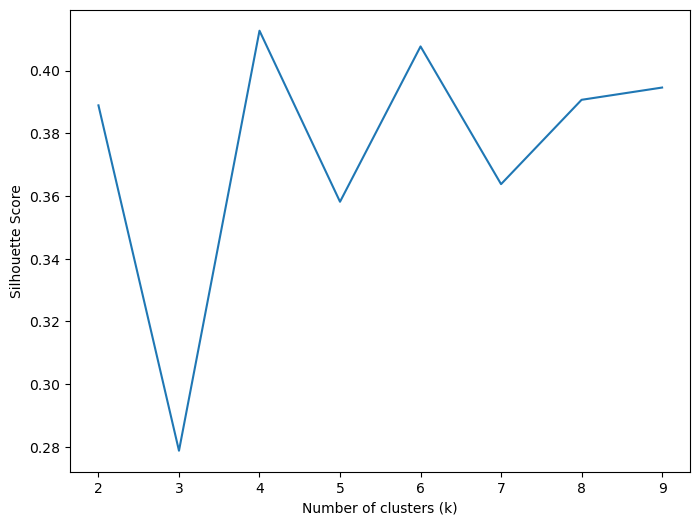

In [26]:
silhouette_arr = silhouette_vs_k(
    balanced, assembler_inputs, indexer, encoder, assembler, max_k=10
)

The highest Silhouette Score is observed for k = 4 (0.413), but k = 2 also shows a relatively high score (0.389). This suggests that while k = 4 might provide slightly better cluster separation, k = 2 is also a reasonable choice. In general, the Silhouette Scores across different k values are fairly close, indicating that several cluster counts could be considered suitable depending on the desired level of granularity